<a href="https://colab.research.google.com/github/smrithi94/PGP_ML_SQL_DATA/blob/main/Restaurant_Analysis_refined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

# Predicting annual turnover of a restaurant after performing EDA and regression.

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#to show the entire description
pd.set_option('display.max_colwidth', None)

In [ ]:
data_description = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackathon/Data_Dictionary.csv')

# Loading Dataset

In [ ]:
df_restaurant = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackathon/Train_dataset.csv')

In [ ]:
data = df_restaurant.copy()

# Data Overview

In [ ]:
data.head()

,Registration Number,Annual Turnover,Cuisine,City,Restaurant Location,Opening Day of Restaurant,Facebook Popularity Quotient,Endorsed By,Instagram Popularity Quotient,Fire Audit,...,Overall Restaurant Rating,Live Music Rating,Comedy Gigs Rating,Value Deals Rating,Live Sports Rating,Ambience,Lively,Service,Comfortablility,Privacy
0,60001,42000000,"indian,irish",Bangalore,Near Business Hub,14-02-2009,84.3,Not Specific,95.8,1,...,10.0,4.0,NaN,NaN,NaN,8.0,8,6,6,6
1,60002,50000000,"indian,irish",Indore,Near Party Hub,29-09-2008,85.4,Tier A Celebrity,85.0,1,...,9.0,NaN,4.0,NaN,NaN,5.0,7,7,3,8
2,60003,32500000,"tibetan,italian",Chennai,Near Business Hub,30-07-2011,85.0,Tier A Celebrity,68.2,1,...,8.0,3.0,NaN,NaN,NaN,7.0,10,5,2,8
3,60004,110000000,"turkish,nigerian",Gurgaon,Near Party Hub,30-11-2008,85.6,Tier A Celebrity,83.6,0,...,9.0,6.0,NaN,NaN,NaN,7.0,7,4,3,5
4,60005,20000000,"irish,belgian",Manesar,Near Party Hub,22-02-2010,NaN,Tier A Celebrity,76.8,1,...,6.0,NaN,2.0,NaN,NaN,NaN,6,2,4,6


In [ ]:
data.tail()

,Registration Number,Annual Turnover,Cuisine,City,Restaurant Location,Opening Day of Restaurant,Facebook Popularity Quotient,Endorsed By,Instagram Popularity Quotient,Fire Audit,...,Overall Restaurant Rating,Live Music Rating,Comedy Gigs Rating,Value Deals Rating,Live Sports Rating,Ambience,Lively,Service,Comfortablility,Privacy
3488,63489,40500000,"algerian,belgian",-1,Near Party Hub,20-03-2009,69.10,Not Specific,62.11,1,...,9.0,5.0,NaN,NaN,NaN,7.0,7,6,6,8
3489,63490,32500000,"tibetan,greek",Bangalore,Near Party Hub,05-02-2012,91.00,Not Specific,96.30,1,...,NaN,4.0,NaN,NaN,NaN,4.0,9,4,0,5
3490,63491,42500000,"indian,irish",Chennai,Near Party Hub,21-05-2009,80.83,Not Specific,86.80,1,...,8.0,NaN,NaN,NaN,3.0,6.0,8,3,3,7
3491,63492,53000000,"japanese,thai",Bangalore,Near Party Hub,22-06-2008,79.40,Not Specific,86.00,1,...,7.0,3.0,2.0,NaN,NaN,7.0,6,3,3,6
3492,63493,12000000,"indian,irish",Ghaziabad,Near Party Hub,23-04-2009,72.00,Not Specific,67.00,1,...,NaN,1.0,NaN,NaN,NaN,6.0,9,6,3,8


In [ ]:
print('There are',data.shape[0],'rows and' ,data.shape[1],'columns in the dataset')

There are 3493 rows and 34 columns in the dataset


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3493 entries, 0 to 3492
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Registration Number            3493 non-null   int64  
 1   Annual Turnover                3493 non-null   int64  
 2   Cuisine                        3493 non-null   object 
 3   City                           3493 non-null   object 
 4   Restaurant Location            3493 non-null   object 
 5   Opening Day of Restaurant      3493 non-null   object 
 6   Facebook Popularity Quotient   3394 non-null   float64
 7   Endorsed By                    3493 non-null   object 
 8   Instagram Popularity Quotient  3437 non-null   float64
 9   Fire Audit                     3493 non-null   int64  
 10  Liquor License Obtained        3493 non-null   int64  
 11  Situated in a Multi Complex    3493 non-null   int64  
 12  Dedicated Parking              3493 non-null   i

Restaurant_tier, facebook popularity, Overall Restaurant Rating, Live Music Rating, Comedy Gigs Rating,Value Deals Rating, Live Sports Rating have null values.

In [ ]:
data['Opening Day of Restaurant'] = pd.to_datetime(data['Opening Day of Restaurant'])

<ipython-input-12-b94067370010>:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data['Opening Day of Restaurant'] = pd.to_datetime(data['Opening Day of Restaurant'])


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Registration Number,3493.0,6.174700e+04,1.008487e+03,60001.0,60874.0,61747.00,6.262000e+04,6.349300e+04
Annual Turnover,3493.0,3.072571e+07,2.165125e+07,3500000.0,18000000.0,30000000.00,3.700000e+07,4.000000e+08
Facebook Popularity Quotient,3394.0,7.793872e+01,9.829169e+00,43.0,72.0,79.00,8.574500e+01,9.776000e+01
Instagram Popularity Quotient,3437.0,7.440468e+01,1.094033e+01,40.0,66.0,74.05,8.240000e+01,9.870000e+01
Fire Audit,3493.0,7.887203e-01,4.082748e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Liquor License Obtained,3493.0,9.882622e-01,1.077187e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Situated in a Multi Complex,3493.0,8.081878e-01,3.937825e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Dedicated Parking,3493.0,8.018895e-01,3.986329e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Open Sitting Available,3493.0,8.001718e-01,3.999284e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Resturant Tier,3444.0,1.926539e+00,2.609297e-01,1.0,2.0,2.00,2.000000e+00,2.000000e+00


# Sanity Check

In [ ]:
data.isnull().sum()

,0
Registration Number,0
Annual Turnover,0
Cuisine,0
City,0
Restaurant Location,0
Opening Day of Restaurant,0
Facebook Popularity Quotient,99
Endorsed By,0
Instagram Popularity Quotient,56
Fire Audit,0


In [ ]:
data.duplicated().sum()

0

In [ ]:
cat_cols = ['City', 'Cuisine','Restaurant Location', 'Endorsed By']

for col in cat_cols:
  print(data[col].value_counts())
  print('-' * 100)

Bangalore      553
-1             396
Noida          324
Hyderabad      295
Pune           262
              ... 
Miryalaguda      1
 mumbai          1
Dharuhera        1
meerut           1
pondy            1
Name: City, Length: 297, dtype: int64
----------------------------------------------------------------------------------------------------
tibetan,greek          686
welsh,thai             345
tibetan,italian        278
indian,irish           273
british,japanese       271
turkish,nigerian       225
japanese,thai          204
chinese,salvadorian    159
algerian,belgian       155
turkish,sapnish        147
polish,jewish          117
peruvian,cuban         115
swedish,greek           92
irish,belgian           85
algerian,korean         83
cuban,british           81
algerian,algerian       67
hawaiian,latvian        46
british,belgian         40
nigerian,cajun          24
Name: Cuisine, dtype: int64
------------------------------------------------------------------------------------

In [ ]:
data['City']. unique()
data['City'] = data['City'].replace('-1', 'Unknown')

In [ ]:
#removing whitespaces
data['City'] = data['City'].str.strip()

In [ ]:
#standardizing the case
data['City'] = data['City'].str.lower()

In [ ]:

#mapping cities to the corresponding right names
city_mapping = {
    'bangalore': 'bangalore',
    'banglore': 'bangalore',
    'banagalore': 'bangalore',
    'bengaluru': 'bangalore',
    'bangalore ': 'bangalore',
    'bangalore': 'bangalore',
    'bengaluru': 'bangalore',

    'delhi': 'delhi',
    'new delhi': 'delhi',
    'new delhi ': 'delhi',
    'delhi/ncr': 'delhi',
    ' delhi': 'delhi',
    'DELHI': 'delhi',

    'hyderabad': 'hyderabad',
    'hyderabad ': 'hyderabad',
    'hderabad': 'hyderabad',
    'hyderabad(bhadurpally)': 'hyderabad',

    'noida': 'noida',
    'noida ': 'noida',
    'nouda': 'noida',
    'greater noida': 'noida',
    'greater noida ': 'noida',
    'GREATER NOIDA': 'noida',

    'mumbai ': 'mumbai',
    'mumbai': 'mumbai',
    'navi mumbai': 'mumbai',
    'navi mumbai , hyderabad': 'mumbai',
    'mumbai ': 'mumbai',
    'navi mumbai ': 'mumbai',

    'pune': 'pune',
    'pune ': 'pune',

    'gurgaon': 'gurgaon',
    'gurgoan': 'gurgaon',
    'gurgoan ': 'gurgaon',
    'gurgaon ': 'gurgaon',
    'gurga': 'gurgaon',
    'GURGOAN': 'gurgaon',
}

data['City'] = data['City'].replace(city_mapping)

In [ ]:
city_counts = data['City'].value_counts()
data['City'] = data['City'].apply(lambda x: x if city_counts[x] >= 100 else 'other')

In [ ]:
data['City'].value_counts()

,City
bangalore,602
other,592
unknown,396
noida,373
hyderabad,327
pune,295
chennai,283
delhi,200
gurgaon,196
mumbai,123


Here I see about 11% of the cities have unknown values. I prefer to keep it as is for two reasons.

adding the mode city in place of unknown may create a biased dataset and may lead to overfit.
cannot drop it because it is significantly large. Hence I have the city as is now.

In [ ]:
data['Resturant Tier'] = data['Resturant Tier'].fillna(2.0)


We should consider dropping the columns Comedy Gigs Rating, Value Deals Rating, Live Sports Rating since atleast 70% of the data is Null

In [ ]:
data.drop(['Comedy Gigs Rating', 'Value Deals Rating', 'Live Sports Rating'], axis=1, inplace=True)

Since all these are variables of type continuous and ordinal we try to fill the null values accordingly

In [ ]:
# Use median to fill continuous values.
data['Facebook Popularity Quotient'] = data['Facebook Popularity Quotient'].fillna(data['Facebook Popularity Quotient'].median())
data['Instagram Popularity Quotient'] = data['Instagram Popularity Quotient'].fillna(data['Instagram Popularity Quotient'].median())

In [ ]:
data.isnull().sum()[data.isnull().sum()>0]

,0
Overall Restaurant Rating,212
Live Music Rating,765
Ambience,25


Since these are ordinal values, we can refer to the median of the corresponding cuisine types to fill in the Overall Restaurant Rating and Live Music Rating and Ambience.

In [ ]:
data['Primary Cuisine'] = data['Cuisine'].str.split(',').str[0].str.strip().str.lower()

In [ ]:
rating_by_cuisine = (
    data[data['Overall Restaurant Rating'].notnull()]
    .groupby('Primary Cuisine')['Overall Restaurant Rating']
    .median()
)

In [ ]:
def fill_rating(row):
    if pd.isnull(row['Overall Restaurant Rating']):
        return rating_by_cuisine.get(row['Primary Cuisine'], data['Overall Restaurant Rating'].median())
    else:
        return row['Overall Restaurant Rating']

data['Overall Restaurant Rating'] = data.apply(fill_rating, axis=1)

In [ ]:
def fill_rating_lmr(row):
    if pd.isnull(row['Live Music Rating']):
        return rating_by_cuisine.get(row['Live Music Rating'], data['Live Music Rating'].median())
    else:
        return row['Live Music Rating']

data['Live Music Rating'] = data.apply(fill_rating_lmr, axis=1)

In [ ]:
def fill_rating_amb(row):
    if pd.isnull(row['Ambience']):
        return rating_by_cuisine.get(row['Ambience'], data['Ambience'].median())
    else:
        return row['Ambience']

In [ ]:
data['Ambience'] = data.apply(fill_rating_amb, axis=1)

In [ ]:
data.isnull().sum()[data.isnull().sum()>0]

,0


In [ ]:
data.columns

Index(['Registration Number', 'Annual Turnover', 'Cuisine', 'City',
       'Restaurant Location', 'Opening Day of Restaurant',
       'Facebook Popularity Quotient', 'Endorsed By',
       'Instagram Popularity Quotient', 'Fire Audit',
       'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Open Sitting Available', 'Resturant Tier',
       'Restaurant Type', 'Restaurant Theme', 'Restaurant Zomato Rating',
       'Restaurant City Tier', 'Order Wait Time', 'Staff Responsivness',
       'Value for Money', 'Hygiene Rating', 'Food Rating',
       'Overall Restaurant Rating', 'Live Music Rating', 'Ambience', 'Lively',
       'Service', 'Comfortablility', 'Privacy', 'Primary Cuisine'],
      dtype='object')

In [ ]:
data.to_csv("/content/drive/MyDrive/Colab Notebooks/Hackathon/clean_data.csv", index=False)

# Feature Engineering

In [ ]:
today = pd.to_datetime('today')
data['Years_in_Business'] = (today - data['Opening Day of Restaurant']).dt.days // 365

In [ ]:
data.drop('Opening Day of Restaurant', axis=1, inplace=True)

In [ ]:
data.drop('Endorsed By', axis= 1 ,inplace = True)

In [ ]:
drop_cols = ['Registration Number', 'Cuisine', 'Restaurant Type']

In [ ]:
data.drop(columns=drop_cols, inplace=True)

In [ ]:
data.head()

,Annual Turnover,City,Restaurant Location,Facebook Popularity Quotient,Instagram Popularity Quotient,Fire Audit,Liquor License Obtained,Situated in a Multi Complex,Dedicated Parking,Open Sitting Available,...,Food Rating,Overall Restaurant Rating,Live Music Rating,Ambience,Lively,Service,Comfortablility,Privacy,Primary Cuisine,Years_in_Business
0,42000000,bangalore,Near Business Hub,84.3,95.8,1,1,1,0,1,...,7,10.0,4.0,8.0,8,6,6,6,indian,16
1,50000000,other,Near Party Hub,85.4,85.0,1,1,1,1,0,...,8,9.0,4.0,5.0,7,7,3,8,indian,16
2,32500000,chennai,Near Business Hub,85.0,68.2,1,1,1,1,0,...,7,8.0,3.0,7.0,10,5,2,8,tibetan,13
3,110000000,gurgaon,Near Party Hub,85.6,83.6,0,1,1,1,1,...,8,9.0,6.0,7.0,7,4,3,5,turkish,16
4,20000000,other,Near Party Hub,79.0,76.8,1,1,1,1,1,...,8,6.0,4.0,7.0,6,2,4,6,irish,15


In [ ]:
label_encode_cols = ['Restaurant Location']
for col in label_encode_cols:
    data[col] = data[col].astype('category').cat.codes

In [ ]:
data.columns

Index(['Annual Turnover', 'City', 'Restaurant Location',
       'Facebook Popularity Quotient', 'Instagram Popularity Quotient',
       'Fire Audit', 'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Open Sitting Available', 'Resturant Tier',
       'Restaurant Theme', 'Restaurant Zomato Rating', 'Restaurant City Tier',
       'Order Wait Time', 'Staff Responsivness', 'Value for Money',
       'Hygiene Rating', 'Food Rating', 'Overall Restaurant Rating',
       'Live Music Rating', 'Ambience', 'Lively', 'Service', 'Comfortablility',
       'Privacy', 'Primary Cuisine', 'Years_in_Business'],
      dtype='object')

In [ ]:
one_hot_cols = ['Primary Cuisine', 'City', 'Restaurant Theme', 'Primary Cuisine']
data = pd.get_dummies(data, columns=one_hot_cols, drop_first=True)

In [ ]:
data

,Annual Turnover,Restaurant Location,Facebook Popularity Quotient,Instagram Popularity Quotient,Fire Audit,Liquor License Obtained,Situated in a Multi Complex,Dedicated Parking,Open Sitting Available,Resturant Tier,...,Primary Cuisine_indian,Primary Cuisine_irish,Primary Cuisine_japanese,Primary Cuisine_nigerian,Primary Cuisine_peruvian,Primary Cuisine_polish,Primary Cuisine_swedish,Primary Cuisine_tibetan,Primary Cuisine_turkish,Primary Cuisine_welsh
0,42000000,0,84.30,95.80,1,1,1,0,1,2.0,...,1,0,0,0,0,0,0,0,0,0
1,50000000,1,85.40,85.00,1,1,1,1,0,2.0,...,1,0,0,0,0,0,0,0,0,0
2,32500000,0,85.00,68.20,1,1,1,1,0,2.0,...,0,0,0,0,0,0,0,1,0,0
3,110000000,1,85.60,83.60,0,1,1,1,1,1.0,...,0,0,0,0,0,0,0,0,1,0
4,20000000,1,79.00,76.80,1,1,1,1,1,2.0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3488,40500000,1,69.10,62.11,1,1,0,1,1,2.0,...,0,0,0,0,0,0,0,0,0,0
3489,32500000,1,91.00,96.30,1,1,0,1,0,2.0,...,0,0,0,0,0,0,0,1,0,0
3490,42500000,1,80.83,86.80,1,1,1,1,0,2.0,...,1,0,0,0,0,0,0,0,0,0
3491,53000000,1,79.40,86.00,1,1,1,1,1,2.0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
data.columns

Index(['Annual Turnover', 'Restaurant Location',
       'Facebook Popularity Quotient', 'Instagram Popularity Quotient',
       'Fire Audit', 'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Open Sitting Available', 'Resturant Tier',
       'Restaurant Zomato Rating', 'Restaurant City Tier', 'Order Wait Time',
       'Staff Responsivness', 'Value for Money', 'Hygiene Rating',
       'Food Rating', 'Overall Restaurant Rating', 'Live Music Rating',
       'Ambience', 'Lively', 'Service', 'Comfortablility', 'Privacy',
       'Years_in_Business', 'Primary Cuisine_british',
       'Primary Cuisine_chinese', 'Primary Cuisine_cuban',
       'Primary Cuisine_hawaiian', 'Primary Cuisine_indian',
       'Primary Cuisine_irish', 'Primary Cuisine_japanese',
       'Primary Cuisine_nigerian', 'Primary Cuisine_peruvian',
       'Primary Cuisine_polish', 'Primary Cuisine_swedish',
       'Primary Cuisine_tibetan', 'Primary Cuisine_turkish',
       'Primary Cuisin

In [ ]:
data = data.loc[:, ~data.columns.duplicated()]

In [ ]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(float)

In [ ]:
data.head()


,Annual Turnover,Restaurant Location,Facebook Popularity Quotient,Instagram Popularity Quotient,Fire Audit,Liquor License Obtained,Situated in a Multi Complex,Dedicated Parking,Open Sitting Available,Resturant Tier,...,Restaurant Theme_Parsi,Restaurant Theme_Petit,Restaurant Theme_Picante,Restaurant Theme_Piquant,Restaurant Theme_Resca,Restaurant Theme_Sage,Restaurant Theme_Savory,Restaurant Theme_Spoon,Restaurant Theme_TheGem,Restaurant Theme_Umami
0,42000000,0,84.3,95.8,1,1,1,0,1,2.0,...,0,0,0,0,0,0,0,0,0,0
1,50000000,1,85.4,85.0,1,1,1,1,0,2.0,...,0,0,0,0,0,0,0,0,0,0
2,32500000,0,85.0,68.2,1,1,1,1,0,2.0,...,0,0,0,0,0,0,0,0,0,0
3,110000000,1,85.6,83.6,0,1,1,1,1,1.0,...,0,0,0,0,0,0,0,0,0,0
4,20000000,1,79.0,76.8,1,1,1,1,1,2.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data.shape

(3493, 82)

In [ ]:
X = data.drop('Annual Turnover', axis=1)
y = data['Annual Turnover']

In [ ]:
y_log = np.log1p(y)  # log(1 + y) is safe for 0s

# Step 2: Add constant to predictors
X = sm.add_constant(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(2794, 82)

# Split and Train

In [ ]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Annual Turnover   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     6.743
Date:                Sat, 07 Jun 2025   Prob (F-statistic):           3.61e-61
Time:                        05:10:56   Log-Likelihood:                -50916.
No. Observations:                2794   AIC:                         1.020e+05
Df Residuals:                    2714   BIC:                         1.025e+05
Df Model:                          79                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# we will define a function to check VIF
def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif.sort_values(by="VIF", ascending=False)

In [ ]:
pd.set_option('display.max_rows', None)
checking_vif(X_train)

In [ ]:
X=X.drop(['Restaurant Theme_LaCuisine', 'Restaurant Theme_Spoon'], axis =1)

In [ ]:
model_pruned = sm.OLS(y, X_pruned).fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
0,const,564.482996
36,Primary Cuisine_tibetan,3.194345
64,Restaurant Theme_Greek,2.127344
50,Restaurant Theme_Arabian,2.097798
37,Primary Cuisine_turkish,2.066130
38,Primary Cuisine_welsh,2.035480
3,Instagram Popularity Quotient,2.033928
2,Facebook Popularity Quotient,1.997404
25,Primary Cuisine_british,1.915064
20,Lively,1.833861


In [ ]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [ ]:
col_list = ["RAD", "TAX"]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[ 0.        ,  0.55998858,  1.17278481, ...,  0.        ,
        -0.04234096, -0.02676439],
       [ 0.        ,  0.55998858,  0.14470274, ...,  0.        ,
        -0.04234096, -0.02676439],
       [ 0.        , -1.7857507 ,  0.30919587, ...,  0.        ,
        -0.04234096, -0.02676439],
       ...,
       [ 0.        ,  0.55998858,  1.09465057, ...,  0.        ,
        -0.04234096, -0.02676439],
       [ 0.        , -1.7857507 ,  0.7204287 , ...,  0.        ,
        -0.04234096, -0.02676439],
       [ 0.        , -1.7857507 ,  1.78963405, ...,  0.        ,
        -0.04234096, -0.02676439]])

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

In [ ]:
rmse_lin

np.float64(19481741.80518853)

Feature Importance Analysis


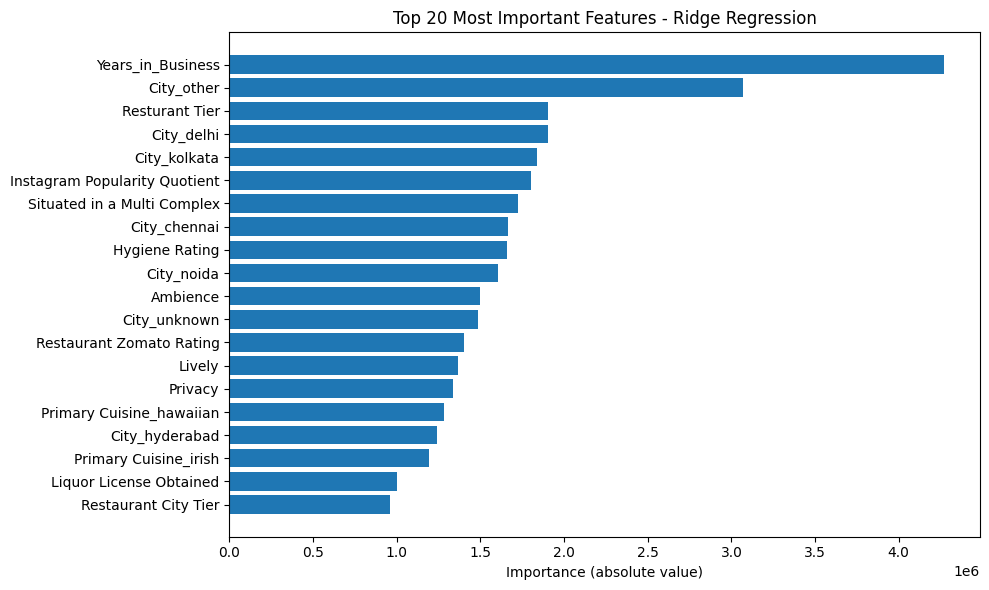

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

feature_names = X.columns

# Get coefficients from Ridge model
ridge_coef = ridge.coef_

# Create a DataFrame to view importance
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_coef,
    'Importance (abs)': np.abs(ridge_coef)
}).sort_values(by='Importance (abs)', ascending=False)

# Top 20 features
top_features = coef_df.head(20)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance (abs)'][::-1])
plt.xlabel('Importance (absolute value)')
plt.title('Top 20 Most Important Features - Ridge Regression')
plt.tight_layout()
plt.show()

Dropping irrelavant features

In [ ]:
low_importance_features = coef_df[coef_df['Importance (abs)'] < 1e5]['Feature'].tolist()

print(f"Dropping {len(low_importance_features)} low-importance features")

# Drop from X
X_reduced = X.drop(columns=low_importance_features)
expected_columns = X_reduced.columns.tolist()
expected_columns
low_importance_features

Dropping 11 low-importance features


['Restaurant Theme_Delicio',
 'Restaurant Theme_Downtown',
 'Order Wait Time',
 'Primary Cuisine_nigerian',
 'Restaurant Theme_Benedicta',
 'Restaurant Theme_Savory',
 'Restaurant Theme_TheGem',
 'Open Sitting Available',
 'const',
 'Restaurant Theme_LaCuisine',
 'Restaurant Theme_Spoon']

In [ ]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
X_train_red.columns

Index(['Restaurant Location', 'Facebook Popularity Quotient',
       'Instagram Popularity Quotient', 'Fire Audit',
       'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Resturant Tier', 'Restaurant Zomato Rating',
       'Restaurant City Tier', 'Staff Responsivness', 'Value for Money',
       'Hygiene Rating', 'Food Rating', 'Overall Restaurant Rating',
       'Live Music Rating', 'Ambience', 'Lively', 'Service', 'Comfortablility',
       'Privacy', 'Years_in_Business', 'Primary Cuisine_british',
       'Primary Cuisine_chinese', 'Primary Cuisine_cuban',
       'Primary Cuisine_hawaiian', 'Primary Cuisine_indian',
       'Primary Cuisine_irish', 'Primary Cuisine_japanese',
       'Primary Cuisine_peruvian', 'Primary Cuisine_polish',
       'Primary Cuisine_swedish', 'Primary Cuisine_tibetan',
       'Primary Cuisine_turkish', 'Primary Cuisine_welsh', 'City_chennai',
       'City_delhi', 'City_gurgaon', 'City_hyderabad', 'City_kolkata',
       'C

In [ ]:
scaler2 = StandardScaler()
X_train_scaled_red = scaler2.fit_transform(X_train_red)
X_test_scaled_red = scaler2.transform(X_test_red)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_scaled_red, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Best Ridge Alpha:", ridge_cv.best_params_)
print(f"Tuned Ridge RMSE: ₹{abs(ridge_cv.best_score_):,.2f}")

Best Ridge Alpha: {'alpha': 1000}
Tuned Ridge RMSE: ₹19,923,802.40


In [ ]:
from sklearn.linear_model import Lasso

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_root_mean_squared_error')
lasso_cv.fit(X_train_scaled_red, y_train)
print("Best Lasso Alpha:", lasso_cv.best_params_)
print(f"Tuned Lasso RMSE: ₹{abs(lasso_cv.best_score_):,.2f}")

Best Lasso Alpha: {'alpha': 100}
Tuned Lasso RMSE: ₹20,015,592.92


In [ ]:
ridge_final = Ridge(alpha=1000)
ridge_final.fit(X_train_scaled_red, y_train)
y_pred_ridge = ridge_final.predict(X_test_scaled_red)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Final Ridge RMSE on Test Set: ₹{rmse_ridge:,.2f}")

Final Ridge RMSE on Test Set: ₹19,482,476.93


In [ ]:
# Lasso final model
lasso_final = Lasso(alpha=100)
lasso_final.fit(X_train_scaled_red, y_train)
y_pred_lasso = lasso_final.predict(X_test_scaled_red)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print(f"Final Lasso RMSE on Test Set: ₹{rmse_lasso:,.2f}")

Final Lasso RMSE on Test Set: ₹19,483,325.89


## Test Data

In [ ]:
df_restaurant_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackathon/Test_dataset.csv')

In [ ]:
data_test = df_restaurant_test.copy()

In [ ]:
data_test.isnull().sum()

,0
Registration Number,0
Cuisine,0
City,0
Restaurant Location,0
Opening Day of Restaurant,0
Facebook Popularity Quotient,0
Endoresed By,0
Instagram Popularity Quotient,0
Fire Audit,0
Liquor License Obtained,0


In [ ]:
data_test.duplicated().sum()

np.int64(0)

In [ ]:
cat_cols = ['City', 'Cuisine','Restaurant Location', 'Endoresed By']

In [ ]:

for col in cat_cols:
  print(data_test[col].value_counts())
  print('-' * 100)


City
Bangalore               74
-1                      65
Noida                   44
Hyderabad               40
Chennai                 28
Pune                    28
Gurgaon                 24
New Delhi               20
Mumbai                  18
Jaipur                  10
Kolkata                 10
Navi Mumbai             10
Lucknow                  8
Chandigarh               5
Nagpur                   4
Coimbatore               4
Mysore                   4
Ahmedabad                3
Indore                   3
kolkata                  3
Bangalore                3
pune                     3
Banglore                 2
hyderabad                2
mohali                   2
Gurgaon                  2
Faridabad                2
CHENNAI                  2
Dehradun                 2
 Mumbai                  2
Delhi                    2
Bhubaneswar              2
Bhopal                   2
Bhubaneshwar             2
Raipur                   2
Greater Noida            2
sambalpur              

In [ ]:

data_test['City']. unique()
data_test['City'] = data_test['City'].replace('-1', 'Unknown')

In [ ]:
#removing whitespaces
data_test['City'] = data_test['City'].str.strip()


In [ ]:
#standardizing the case
data_test['City'] = data_test['City'].str.lower()

In [ ]:

data_test['City'] = data_test['City'].replace(city_mapping)

In [ ]:
city_counts = data_test['City'].value_counts()
data_test['City'] = data_test['City'].apply(lambda x: x if city_counts[x] >= 50 else 'other')

In [ ]:
city_counts = data_test['City'].value_counts()
city_counts

,count
City,
other,352
bangalore,83
unknown,65


In [ ]:
data_test['Resturant Tier'] = data_test['Resturant Tier'].fillna(2.0)
data_test.drop(['Comedy Gigs Rating', 'Value Deals Rating', 'Live Sports Rating'], axis=1, inplace=True)

In [ ]:
data_test['Facebook Popularity Quotient'] = data_test['Facebook Popularity Quotient'].fillna(data_test['Facebook Popularity Quotient'].median())
data_test['Instagram Popularity Quotient'] = data_test['Instagram Popularity Quotient'].fillna(data_test['Instagram Popularity Quotient'].median())


In [ ]:
data_test.isnull().sum()[data_test.isnull().sum()>0]

,0
Overall Restaurant Rating,34
Live Music Rating,102


In [ ]:
data_test['Primary Cuisine'] = data_test['Cuisine'].str.split(',').str[0].str.strip().str.lower()

In [ ]:
rating_by_cuisine = (
    data_test[data_test['Overall Restaurant Rating'].notnull()]
    .groupby('Primary Cuisine')['Overall Restaurant Rating']
    .median()
)

In [ ]:

def fill_rating(row):
    if pd.isnull(row['Overall Restaurant Rating']):
        return rating_by_cuisine.get(row['Primary Cuisine'], data_test['Overall Restaurant Rating'].median())
    else:
        return row['Overall Restaurant Rating']

In [ ]:
data_test['Overall Restaurant Rating'] = data_test.apply(fill_rating, axis=1)


In [ ]:
def fill_rating_lmr(row):
    if pd.isnull(row['Live Music Rating']):
        return rating_by_cuisine.get(row['Live Music Rating'], data_test['Live Music Rating'].median())
    else:
        return row['Live Music Rating']


In [ ]:

data_test['Live Music Rating'] = data_test.apply(fill_rating_lmr, axis=1)

In [ ]:

def fill_rating_amb(row):
    if pd.isnull(row['Ambience']):
        return rating_by_cuisine.get(row['Ambience'], data_test['Ambience'].median())
    else:
        return row['Ambience']

data_test['Ambience'] = data_test.apply(fill_rating_amb, axis=1)

In [ ]:
data_test.isnull().sum()[data_test.isnull().sum()>0]

,0


In [ ]:
today = pd.to_datetime('today')
data_test['Opening Day of Restaurant'] = pd.to_datetime(data_test['Opening Day of Restaurant'])
data_test['Years_in_Business'] = (today - data_test['Opening Day of Restaurant']).dt.days // 365

<ipython-input-94-31bde790e2e4>:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_test['Opening Day of Restaurant'] = pd.to_datetime(data_test['Opening Day of Restaurant'])


In [ ]:

data_test.drop('Opening Day of Restaurant', axis=1, inplace=True)

data_test.drop('Endoresed By', axis= 1 ,inplace = True)

In [ ]:
reg_numbers = data_test["Registration Number"]

In [ ]:

drop_cols = ['Registration Number', 'Cuisine', 'Restaurant Type']

In [ ]:

data_test.drop(columns=drop_cols, inplace=True)

In [ ]:

label_encode_cols = ['Restaurant Location']
for col in label_encode_cols:
    data_test[col] = data_test[col].astype('category').cat.codes

In [ ]:
one_hot_cols = ['Primary Cuisine', 'City', 'Restaurant Theme', 'Primary Cuisine']
data_test = pd.get_dummies(data_test, columns=one_hot_cols, drop_first=True)

In [ ]:

data_test = data_test.loc[:, ~data_test.columns.duplicated()]

In [ ]:

bool_cols = data_test.select_dtypes(include='bool').columns
data_test[bool_cols] = data_test[bool_cols].astype(float)

In [ ]:
data_test.columns

Index(['Restaurant Location', 'Facebook Popularity Quotient',
       'Instagram Popularity Quotient', 'Fire Audit',
       'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Open Sitting Available', 'Resturant Tier',
       'Restaurant Zomato Rating', 'Restaurant City Tier', 'Order Wait Time',
       'Staff Responsivness', 'Value for Money', 'Hygiene Rating',
       'Food Rating', 'Overall Restaurant Rating', 'Live Music Rating',
       'Ambience', 'Lively', 'Service', 'Comfortablility', 'Privacy',
       'Years_in_Business', 'Primary Cuisine_british',
       'Primary Cuisine_chinese', 'Primary Cuisine_cuban',
       'Primary Cuisine_hawaiian', 'Primary Cuisine_indian',
       'Primary Cuisine_irish', 'Primary Cuisine_japanese',
       'Primary Cuisine_nigerian', 'Primary Cuisine_peruvian',
       'Primary Cuisine_polish', 'Primary Cuisine_swedish',
       'Primary Cuisine_tibetan', 'Primary Cuisine_turkish',
       'Primary Cuisine_welsh', 'City_oth

In [ ]:
X_test = data_test.copy()

In [ ]:
training_columns = [
    'Restaurant Location', 'Facebook Popularity Quotient',
    'Instagram Popularity Quotient', 'Fire Audit',
    'Liquor License Obtained', 'Situated in a Multi Complex',
    'Dedicated Parking', 'Resturant Tier', 'Restaurant Zomato Rating',
    'Restaurant City Tier', 'Staff Responsivness', 'Value for Money',
    'Hygiene Rating', 'Food Rating', 'Overall Restaurant Rating',
    'Live Music Rating', 'Ambience', 'Lively', 'Service', 'Comfortablility',
    'Privacy', 'Years_in_Business', 'Primary Cuisine_british',
    'Primary Cuisine_chinese', 'Primary Cuisine_cuban',
    'Primary Cuisine_hawaiian', 'Primary Cuisine_indian',
    'Primary Cuisine_irish', 'Primary Cuisine_japanese',
    'Primary Cuisine_peruvian', 'Primary Cuisine_polish',
    'Primary Cuisine_swedish', 'Primary Cuisine_tibetan',
    'Primary Cuisine_turkish', 'Primary Cuisine_welsh', 'City_chennai',
    'City_delhi', 'City_gurgaon', 'City_hyderabad', 'City_kolkata',
    'City_mumbai', 'City_noida', 'City_other', 'City_pune', 'City_unknown',
    'Restaurant Theme_Ambiance', 'Restaurant Theme_Arabian',
    'Restaurant Theme_Bakery', 'Restaurant Theme_Belise',
    'Restaurant Theme_Bettaso', 'Restaurant Theme_Cafepro',
    'Restaurant Theme_Carbone', 'Restaurant Theme_Chinese',
    'Restaurant Theme_Cinnamon', 'Restaurant Theme_English',
    'Restaurant Theme_Flavors', 'Restaurant Theme_Grand',
    'Restaurant Theme_Greek', 'Restaurant Theme_Italica',
    'Restaurant Theme_Marco', 'Restaurant Theme_Mise En',
    'Restaurant Theme_Molino', 'Restaurant Theme_Moonrise',
    'Restaurant Theme_Nature', 'Restaurant Theme_Parsi',
    'Restaurant Theme_Petit', 'Restaurant Theme_Picante',
    'Restaurant Theme_Piquant', 'Restaurant Theme_Resca',
    'Restaurant Theme_Sage', 'Restaurant Theme_Umami'
]

In [ ]:
X_test = X_test.reindex(columns=expected_columns, fill_value=0)

In [ ]:
assert list(X_test.columns) == training_columns, "❌ Column mismatch still exists!"

In [ ]:
scaler2.transform(X_test)

array([[-1.78575070e+00,  7.71245536e-04, -4.98986921e-01, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02],
       [ 5.59988582e-01,  1.14913892e+00,  2.00738180e+00, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02],
       [ 5.59988582e-01,  6.17620490e-01,  1.07909709e+00, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02],
       ...,
       [ 5.59988582e-01, -5.54393074e-01, -2.76198590e-01, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02],
       [ 5.59988582e-01,  1.58401764e+00,  1.99809895e+00, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02],
       [ 5.59988582e-01, -1.28433135e+00, -5.73249698e-01, ...,
        -1.89218908e-02, -1.89218908e-02, -2.67643864e-02]])

In [ ]:
X_test.columns

Index(['Restaurant Location', 'Facebook Popularity Quotient',
       'Instagram Popularity Quotient', 'Fire Audit',
       'Liquor License Obtained', 'Situated in a Multi Complex',
       'Dedicated Parking', 'Resturant Tier', 'Restaurant Zomato Rating',
       'Restaurant City Tier', 'Staff Responsivness', 'Value for Money',
       'Hygiene Rating', 'Food Rating', 'Overall Restaurant Rating',
       'Live Music Rating', 'Ambience', 'Lively', 'Service', 'Comfortablility',
       'Privacy', 'Years_in_Business', 'Primary Cuisine_british',
       'Primary Cuisine_chinese', 'Primary Cuisine_cuban',
       'Primary Cuisine_hawaiian', 'Primary Cuisine_indian',
       'Primary Cuisine_irish', 'Primary Cuisine_japanese',
       'Primary Cuisine_peruvian', 'Primary Cuisine_polish',
       'Primary Cuisine_swedish', 'Primary Cuisine_tibetan',
       'Primary Cuisine_turkish', 'Primary Cuisine_welsh', 'City_chennai',
       'City_delhi', 'City_gurgaon', 'City_hyderabad', 'City_kolkata',
       'C

In [ ]:
preds = lasso_final.predict(X_test)
preds

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


array([2.95659982e+08, 3.51975680e+08, 3.28175400e+08, 3.34822346e+08,
       3.48419384e+08, 2.82174413e+08, 2.73653722e+08, 3.04603538e+08,
       3.10139344e+08, 2.68590078e+08, 3.03144913e+08, 3.31863063e+08,
       3.38787677e+08, 3.09776609e+08, 2.84817387e+08, 3.08901483e+08,
       3.38196130e+08, 2.72612225e+08, 3.37961960e+08, 2.80241227e+08,
       2.70915680e+08, 3.31899686e+08, 2.83854679e+08, 2.79138361e+08,
       3.25839842e+08, 2.64389363e+08, 3.43411166e+08, 3.29655933e+08,
       3.28846754e+08, 3.34384662e+08, 2.92479466e+08, 3.18196456e+08,
       3.37822040e+08, 3.48305004e+08, 3.06178958e+08, 2.58345688e+08,
       3.29915780e+08, 2.99873129e+08, 2.97042375e+08, 2.59587934e+08,
       3.37542626e+08, 2.71133723e+08, 2.95192670e+08, 2.76855819e+08,
       3.47839245e+08, 2.96006235e+08, 2.68772912e+08, 3.32074757e+08,
       2.97663212e+08, 2.89527804e+08, 3.31902130e+08, 3.28684615e+08,
       2.70271923e+08, 3.10113022e+08, 3.42583080e+08, 3.12692371e+08,
      

In [ ]:
X_test.drop(columns = ['Restaurant Theme_Delicio',
 'Restaurant Theme_Downtown',
 'Order Wait Time',
 'Primary Cuisine_nigerian',
 'Restaurant Theme_Benedicta',
 'Restaurant Theme_Savory',
 'Restaurant Theme_TheGem',
 'Open Sitting Available',
 'Restaurant Theme_LaCuisine',
 'Restaurant Theme_Spoon'],
  axis = 1, inplace = True)

KeyError: "['Restaurant Theme_Delicio', 'Restaurant Theme_Downtown', 'Order Wait Time', 'Primary Cuisine_nigerian', 'Restaurant Theme_Benedicta', 'Restaurant Theme_Savory', 'Restaurant Theme_TheGem', 'Open Sitting Available', 'Restaurant Theme_LaCuisine', 'Restaurant Theme_Spoon'] not found in axis"

In [ ]:
 submission_df = pd.DataFrame({
    "Registration Number": reg_numbers,
    "Annual Turnover": preds
})

In [ ]:
submission_df["Annual Turnover"] = submission_df["Annual Turnover"].round(0).astype(int)

In [ ]:
submission_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Hackathon/submission_11.csv", index=False)